In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [3]:
x_train=np.linspace(-1,1,20)

In [4]:
y_train = np.array([
    -0.6561, -0.3099, -0.59035, -0.50855, -0.285,
    -0.2443, -0.02445, 0.00135, -0.2006, 0.07475,
    -0.1422, 0.06515, 0.15265, 0.3521, 0.28415,
    0.5524, 0.23115, 0.20835, 0.4211, 0.60485
])

In [5]:
x_test = np.linspace(-1, 1, 20)

In [6]:
y_test = np.array([
    -0.69415, -0.451, -0.43005, -0.4484, -0.1475,
    -0.5019, -0.28055, 0.24595, -0.21425, -0.0286,
    0.23415, 0.46575, 0.07955, 0.1973, 0.0719,
    0.3639, 0.5536, 0.3365, 0.50705, 0.33435
])

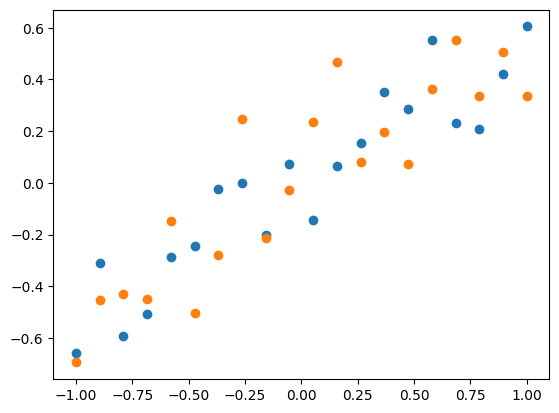

In [7]:
plt.scatter(x_train, y_train)
plt.scatter(x_test,y_test)

In [8]:
model=Sequential()

model.add(Dense(128, activation='relu', input_dim=1))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='linear'))
adam=Adam(learning_rate=0.01)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss='mse', optimizer=adam, metrics=['mse'])

In [10]:
hist=model.fit(x_train, y_train, validation_data=[x_test, y_test], epochs=1000, verbose=0)

In [11]:
train_mse=model.evaluate(x_train, y_train, verbose=0)
test_mse=model.evaluate(x_test, y_test, verbose=0)


In [12]:
print(f'Train: {train_mse}, Test: {test_mse}')

Train: [0.003198727499693632, 0.003198727499693632], Test: [0.051298998296260834, 0.051298998296260834]


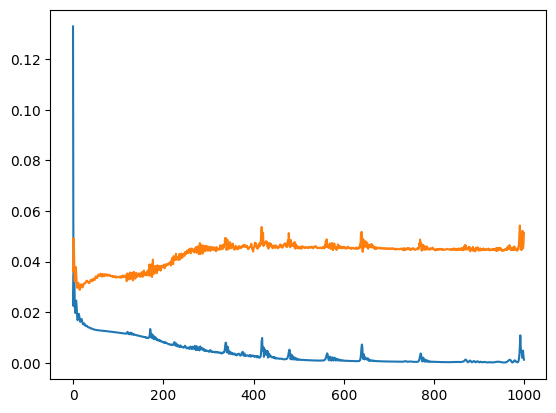

In [13]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])

**In this we can see overfitting because in training-- loss is 0.004 but in training data it is 0.044 which means our model is trying to grasp every point in data without really analyzing the patterns which causes overfitting**

**So for this we need to use Dropout layer**

In [17]:
model2=Sequential()

model2.add(Dense(128, activation='relu', input_dim=1))
model2.add(Dropout(0.5))
model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.5))
model2.add(Dense(1, activation='linear'))

adam1=Adam(learning_rate=0.01)
model2.compile(loss='mse', optimizer=adam1, metrics=['mse'])

In [18]:
hist2=model2.fit(x_train, y_train, validation_data=[x_test, y_test], epochs=500, verbose=0)

In [19]:
train_mse1=model2.evaluate(x_train, y_train, verbose=0)
test_mse1=model2.evaluate(x_test, y_test, verbose=0)
print(f'Train: {train_mse1}, Test: {test_mse1}')

Train: [0.014392919838428497, 0.014392919838428497], Test: [0.03396153450012207, 0.03396153450012207]


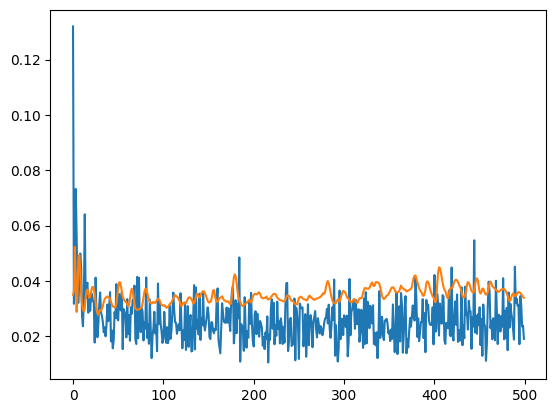

In [20]:
plt.plot(hist2.history['loss'])
plt.plot(hist2.history['val_loss'])

**Now it is Better and overfitting is lower and model is better**

#**Now Let's see using dropouts in Classification Problem**

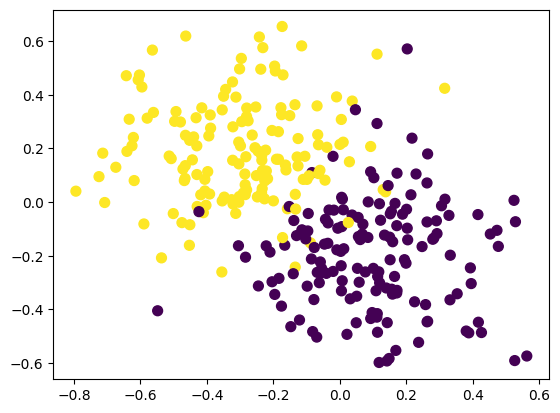

In [28]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Class 0 (purple-like)
class_0 = np.random.randn(150, 2) * 0.2 + np.array([0.1, -0.2])

# Class 1 (yellow-like)
class_1 = np.random.randn(150, 2) * 0.2 + np.array([-0.3, 0.2])

# Combine data
X = np.vstack((class_0, class_1))
y = np.array([0]*150 + [1]*150)

# Shuffle dataset
perm = np.random.permutation(len(X))
X = X[perm]
y = y[perm]

# Plot (same as your image style)
plt.scatter(X[:,0], X[:,1], c=y, s=50)
plt.show()

In [29]:
model3=Sequential()

model3.add(Dense(128, activation='relu', input_dim=2))
model3.add(Dense(128, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))

adam=Adam(learning_rate=0.01)

model3.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

In [30]:
hist4=model3.fit(X,y, validation_split=0.2, epochs=500)

Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9125 - loss: 0.4280 - val_accuracy: 0.9500 - val_loss: 0.1961
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9417 - loss: 0.1833 - val_accuracy: 0.9500 - val_loss: 0.2678
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9417 - loss: 0.1835 - val_accuracy: 0.9500 - val_loss: 0.2378
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9417 - loss: 0.1755 - val_accuracy: 0.9500 - val_loss: 0.2162
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9333 - loss: 0.1699 - val_accuracy: 0.9333 - val_loss: 0.1924
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9333 - loss: 0.1624 - val_accuracy: 0.9500 - val_loss: 0.2132
Epoch 7/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9417 - loss: 0.1629 - val_accuracy: 0.9500 - val_loss: 0.1950
Epoch 8/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9375 - loss: 0.1473 - val_accuracy: 0.9500 - val_loss:

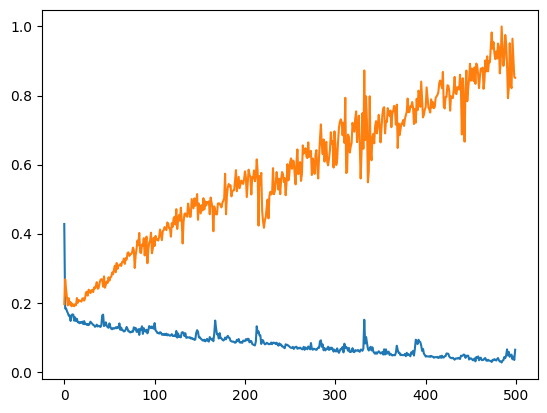

In [31]:
plt.plot(hist4.history['loss'])
plt.plot(hist4.history['val_loss'])

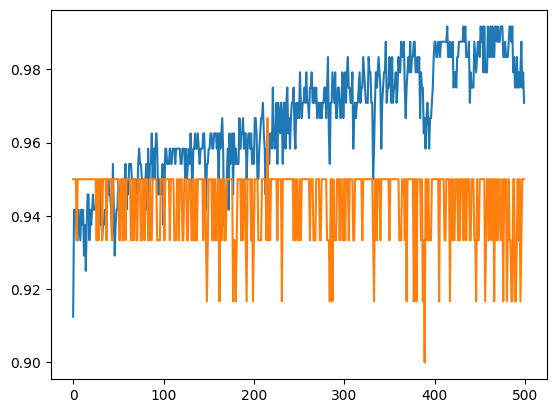

In [32]:
plt.plot(hist4.history['accuracy'])
plt.plot(hist4.history['val_accuracy'])

In [34]:
model4=Sequential()

model4.add(Dense(128, activation='relu', input_dim=2))
model4.add(Dropout(0.5))
model4.add(Dense(128, activation='relu'))
model4.add(Dropout(0.5))
model4.add(Dense(1, activation='sigmoid'))
adam=Adam(learning_rate=0.01)

model4.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
hist5=model4.fit(X,y, epochs=500, validation_split=0.2)

Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9458 - loss: 0.1334 - val_accuracy: 0.9500 - val_loss: 0.1483
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9542 - loss: 0.1248 - val_accuracy: 0.9500 - val_loss: 0.1553
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9583 - loss: 0.1240 - val_accuracy: 0.9500 - val_loss: 0.1658
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9583 - loss: 0.1229 - val_accuracy: 0.9500 - val_loss: 0.1736
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9458 - loss: 0.1310 - val_accuracy: 0.9500 - val_loss: 0.1871
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9583 - loss: 0.1167 - val_accuracy: 0.9500 - val_loss: 0.1976
Epoch 7/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9583 - loss: 0.1146 - val_accuracy: 0.9500 - val_loss: 0.2039
Epoch 8/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9458 - loss: 0.1346 - val_accuracy: 0.9500 - val_loss: